# Data Quality and Exploratory Analysis — Customer Churn




## 1. Import Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

print("Libraries loaded:")
print("pandas", pd.__version__, "| numpy", np.__version__)


Libraries loaded:
pandas 2.2.3 | numpy 2.1.3


## 2. Load Dataset

In [68]:
df_raw = pd.read_csv('customer_churn_sample.csv')

print("First 5 rows:")
display(df_raw.head())


First 5 rows:


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


In [69]:
print("Last 5 rows:")
display(df_raw.tail())


Last 5 rows:


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
10,CUST-1011,Female,49,30,Enterprise,149.99,4499.70,Two Year,0,Credit Card,No
11,CUST-1012,Male,33,14,Pro,79.99,1119.86,Month-to-Month,3,Debit Card,Yes
12,CUST-1013,Female,55,22,Basic,49.99,1099.78,One Year,1,Bank Transfer,No
13,CUST-1014,Male,26,2,Basic,49.99,99.98,Month-to-Month,5,UPI,Yes
14,CUST-1015,Female,43,40,Enterprise,149.99,5999.60,Two Year,1,Credit Card,No


In [70]:
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")
print(f"Column names: {list(df_raw.columns)}")


Number of rows: 15
Number of columns: 11
Column names: ['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod', 'Churn']


In [71]:
print("Data types:")
print(df_raw.dtypes)


Data types:
CustomerID           object
Gender               object
Age                   int64
TenureMonths          int64
SubscriptionType     object
MonthlyCharges      float64
TotalCharges        float64
ContractType         object
SupportTickets        int64
PaymentMethod        object
Churn                object
dtype: object


## 3. Initial Data Profiling



In [72]:
missing_counts = df_raw.isna().sum()
print("Missing values per column:")
print(missing_counts)
print("\nTotal missing cells:", missing_counts.sum())


Missing values per column:
CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64

Total missing cells: 0


In [73]:
full_duplicates = df_raw.duplicated().sum()
id_duplicates = df_raw['CustomerID'].duplicated().sum()
print(f"Fully duplicate rows: {full_duplicates}")
print(f"Duplicate CustomerID values: {id_duplicates}")


Fully duplicate rows: 0
Duplicate CustomerID values: 0


In [74]:
print("Descriptive statistics — numerical columns:")
display(df_raw[['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets']].describe())


Descriptive statistics — numerical columns:


,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,39.066667,18.800000,84.656667,2088.478667,2.533333
std,11.392144,14.333776,42.739521,2407.365767,1.922300
min,23.000000,2.000000,49.990000,99.980000,0.000000
25%,30.000000,7.000000,49.990000,449.910000,1.000000
50%,38.000000,15.000000,79.990000,1099.780000,2.000000
75%,47.000000,27.000000,114.990000,3209.730000,4.000000
max,60.000000,48.000000,149.990000,7199.520000,6.000000


In [75]:
print("Value ranges considered impossible if violated:")
print("TenureMonths < 0:", (df_raw['TenureMonths'] < 0).sum())
print("MonthlyCharges < 0:", (df_raw['MonthlyCharges'] < 0).sum())
print("TotalCharges < 0:", (df_raw['TotalCharges'] < 0).sum())
print("SupportTickets < 0:", (df_raw['SupportTickets'] < 0).sum())
print("Age < 0 or Age > 100:", ((df_raw['Age'] < 0) | (df_raw['Age'] > 100)).sum())


Value ranges considered impossible if violated:
TenureMonths < 0: 0
MonthlyCharges < 0: 0
TotalCharges < 0: 0
SupportTickets < 0: 0
Age < 0 or Age > 100: 0


In [76]:
print("Unique values in categorical columns (checking for inconsistent labels, casing, whitespace):")
for col in ['Gender', 'SubscriptionType', 'ContractType', 'PaymentMethod', 'Churn']:
    print(f"\n{col}: {sorted(df_raw[col].unique())}")


Unique values in categorical columns (checking for inconsistent labels, casing, whitespace):

Gender: ['Female', 'Male']

SubscriptionType: ['Basic', 'Enterprise', 'Pro']

ContractType: ['Month-to-Month', 'One Year', 'Two Year']

PaymentMethod: ['Bank Transfer', 'Credit Card', 'Debit Card', 'UPI']

Churn: ['No', 'Yes']


In [77]:
print("Checking for leading/trailing whitespace in text columns:")
text_cols = df_raw.select_dtypes(include='object').columns
for col in text_cols:
    stripped_diff = (df_raw[col].astype(str) != df_raw[col].astype(str).str.strip()).sum()
    print(f"{col}: {stripped_diff} value(s) with extra whitespace")


Checking for leading/trailing whitespace in text columns:
CustomerID: 0 value(s) with extra whitespace
Gender: 0 value(s) with extra whitespace
SubscriptionType: 0 value(s) with extra whitespace
ContractType: 0 value(s) with extra whitespace
PaymentMethod: 0 value(s) with extra whitespace
Churn: 0 value(s) with extra whitespace


In [78]:
# Cross-check TotalCharges against MonthlyCharges x TenureMonths as a business-logic sanity check
expected_total = (df_raw['MonthlyCharges'] * df_raw['TenureMonths']).round(2)
mismatch = (expected_total - df_raw['TotalCharges']).abs() > 0.01
print(f"Rows where TotalCharges does not match MonthlyCharges x TenureMonths (tolerance 0.01): {mismatch.sum()}")


Rows where TotalCharges does not match MonthlyCharges x TenureMonths (tolerance 0.01): 0


In [79]:
# Outlier check using the IQR method on numerical columns
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets']:
    print(f"{col}: {iqr_outliers(df_raw[col])} potential outlier(s) (IQR method)")


Age: 0 potential outlier(s) (IQR method)
TenureMonths: 0 potential outlier(s) (IQR method)
MonthlyCharges: 0 potential outlier(s) (IQR method)
TotalCharges: 0 potential outlier(s) (IQR method)
SupportTickets: 0 potential outlier(s) (IQR method)


## 4. Cleaning Decisions



In [80]:
cleaning_log = pd.DataFrame([
    {
        "Issue": "Missing values",
        "Column": "All columns",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "Profiling in Section 8 found 0 missing cells across all 11 columns."
    },
    {
        "Issue": "Duplicate rows",
        "Column": "All columns",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "0 fully duplicate rows found; no rows removed."
    },
    {
        "Issue": "Duplicate CustomerID",
        "Column": "CustomerID",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "Every CustomerID value is unique (15 unique IDs for 15 rows)."
    },
    {
        "Issue": "Impossible / negative values",
        "Column": "TenureMonths, MonthlyCharges, TotalCharges, SupportTickets, Age",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "All numerical values fall within logically valid, non-negative ranges."
    },
    {
        "Issue": "Inconsistent categorical labels",
        "Column": "Gender, SubscriptionType, ContractType, PaymentMethod, Churn",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "Each categorical column uses one consistent spelling/casing per category."
    },
    {
        "Issue": "Extra whitespace / formatting",
        "Column": "All text columns",
        "Affected Records": 0,
        "Action Taken": "Applied .str.strip() defensively to all text columns",
        "Reason": "No whitespace issues were detected, but stripping is applied as a safe, "
                  "non-destructive standardization step so the pipeline stays reproducible on "
                  "future, less-clean data loads."
    },
    {
        "Issue": "Incorrect data types",
        "Column": "All columns",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "Pandas already inferred the expected type for every column on load."
    },
    {
        "Issue": "TotalCharges vs MonthlyCharges x TenureMonths consistency",
        "Column": "TotalCharges",
        "Affected Records": 0,
        "Action Taken": "None required",
        "Reason": "TotalCharges matched the expected calculated value for all 15 rows "
                  "(tolerance 0.01)."
    },
    {
        "Issue": "Outliers (IQR method)",
        "Column": "Age, TenureMonths, MonthlyCharges, TotalCharges, SupportTickets",
        "Affected Records": 0,
        "Action Taken": "None required — no values flagged and retained as-is",
        "Reason": "No IQR-based outliers were detected in any numerical column; the sample size "
                  "(n=15) is also too small for reliable outlier removal."
    },
])
display(cleaning_log)
cleaning_log.to_csv('cleaning_log.csv', index=False)
print("Saved cleaning_log.csv")


,Issue,Column,Affected Records,Action Taken,Reason
0,Missing values,All columns,0,None required,Profiling in Section 8 found 0 missing cells a...
1,Duplicate rows,All columns,0,None required,0 fully duplicate rows found; no rows removed.
2,Duplicate CustomerID,CustomerID,0,None required,Every CustomerID value is unique (15 unique ID...
3,Impossible / negative values,"TenureMonths, MonthlyCharges, TotalCharges, Su...",0,None required,All numerical values fall within logically val...
4,Inconsistent categorical labels,"Gender, SubscriptionType, ContractType, Paymen...",0,None required,Each categorical column uses one consistent sp...
5,Extra whitespace / formatting,All text columns,0,Applied .str.strip() defensively to all text c...,"No whitespace issues were detected, but stripp..."
6,Incorrect data types,All columns,0,None required,Pandas already inferred the expected type for ...
7,TotalCharges vs MonthlyCharges x TenureMonths ...,TotalCharges,0,None required,TotalCharges matched the expected calculated v...
8,Outliers (IQR method),"Age, TenureMonths, MonthlyCharges, TotalCharge...",0,None required — no values flagged and retained...,No IQR-based outliers were detected in any num...


Saved cleaning_log.csv


## 5. Data Cleaning



In [81]:
df_clean = df_raw.copy()

# Defensive standardization: strip whitespace on all text columns (safe no-op on this file,
# but keeps the pipeline reproducible if re-run on a less-clean export of the same data).
text_cols = df_clean.select_dtypes(include='object').columns
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Explicit dtype confirmation (no conversion needed — values already match).
df_clean['CustomerID'] = df_clean['CustomerID'].astype(str)
df_clean['Gender'] = df_clean['Gender'].astype('category')
df_clean['SubscriptionType'] = df_clean['SubscriptionType'].astype('category')
df_clean['ContractType'] = df_clean['ContractType'].astype('category')
df_clean['PaymentMethod'] = df_clean['PaymentMethod'].astype('category')
df_clean['Churn'] = df_clean['Churn'].astype('category')

print(f"Rows before cleaning: {len(df_raw)}")
print(f"Rows after cleaning:  {len(df_clean)}")
display(df_clean.head())


Rows before cleaning: 15
Rows after cleaning:  15


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


## 6. Validation Checks

In [82]:
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Remaining full-row duplicates:", df_clean.duplicated().sum())
print("Remaining duplicate CustomerID values:", df_clean['CustomerID'].duplicated().sum())
print()
print("Data types after cleaning:")
print(df_clean.dtypes)


Remaining missing values: 0
Remaining full-row duplicates: 0
Remaining duplicate CustomerID values: 0

Data types after cleaning:
CustomerID            object
Gender              category
Age                    int64
TenureMonths           int64
SubscriptionType    category
MonthlyCharges       float64
TotalCharges         float64
ContractType        category
SupportTickets         int64
PaymentMethod       category
Churn               category
dtype: object


In [83]:
print("Valid numerical ranges:")
print("TenureMonths >= 0:", (df_clean['TenureMonths'] >= 0).all())
print("MonthlyCharges >= 0:", (df_clean['MonthlyCharges'] >= 0).all())
print("TotalCharges >= 0:", (df_clean['TotalCharges'] >= 0).all())
print("SupportTickets >= 0:", (df_clean['SupportTickets'] >= 0).all())


Valid numerical ranges:
TenureMonths >= 0: True
MonthlyCharges >= 0: True
TotalCharges >= 0: True
SupportTickets >= 0: True


In [84]:
valid_contracts = {'Month-to-Month', 'One Year', 'Two Year'}
valid_churn = {'Yes', 'No'}
print("All ContractType values valid:", set(df_clean['ContractType'].unique()).issubset(valid_contracts))
print("All Churn values valid:", set(df_clean['Churn'].unique()).issubset(valid_churn))
print("ContractType categories:", sorted(df_clean['ContractType'].unique()))
print("Churn categories:", sorted(df_clean['Churn'].unique()))


All ContractType values valid: True
All Churn values valid: True
ContractType categories: ['Month-to-Month', 'One Year', 'Two Year']
Churn categories: ['No', 'Yes']


## 7. Before vs After Quality Summary

In [85]:
quality_summary = pd.DataFrame([
    {"Check": "Row count", "Before Cleaning": len(df_raw), "After Cleaning": len(df_clean)},
    {"Check": "Missing values (total cells)", "Before Cleaning": int(df_raw.isna().sum().sum()),
     "After Cleaning": int(df_clean.isna().sum().sum())},
    {"Check": "Full-row duplicates", "Before Cleaning": int(df_raw.duplicated().sum()),
     "After Cleaning": int(df_clean.duplicated().sum())},
    {"Check": "Duplicate CustomerID values", "Before Cleaning": int(df_raw['CustomerID'].duplicated().sum()),
     "After Cleaning": int(df_clean['CustomerID'].duplicated().sum())},
    {"Check": "Negative/impossible numeric values", "Before Cleaning": 0, "After Cleaning": 0},
    {"Check": "Inconsistent categorical labels", "Before Cleaning": 0, "After Cleaning": 0},
    {"Check": "TotalCharges vs Monthly x Tenure mismatches", "Before Cleaning": 0, "After Cleaning": 0},
])
display(quality_summary)
quality_summary.to_csv('data_quality_summary.csv', index=False)
print("Saved data_quality_summary.csv")


,Check,Before Cleaning,After Cleaning
0,Row count,15,15
1,Missing values (total cells),0,0
2,Full-row duplicates,0,0
3,Duplicate CustomerID values,0,0
4,Negative/impossible numeric values,0,0
5,Inconsistent categorical labels,0,0
6,TotalCharges vs Monthly x Tenure mismatches,0,0


Saved data_quality_summary.csv


## 8. Summary Statistics

In [86]:
print("Numerical fields — count, mean, median, min, max, std:")
numeric_cols = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SupportTickets']
summary_stats = df_clean[numeric_cols].agg(['count', 'mean', 'median', 'min', 'max', 'std']).T
display(summary_stats.round(2))


Numerical fields — count, mean, median, min, max, std:


,count,mean,median,min,max,std
Age,15.0,39.07,38.00,23.00,60.00,11.39
TenureMonths,15.0,18.80,15.00,2.00,48.00,14.33
MonthlyCharges,15.0,84.66,79.99,49.99,149.99,42.74
TotalCharges,15.0,2088.48,1099.78,99.98,7199.52,2407.37
SupportTickets,15.0,2.53,2.00,0.00,6.00,1.92


In [87]:
print("Categorical fields — count and percentage distribution:\n")
for col in ['Gender', 'SubscriptionType', 'ContractType', 'PaymentMethod', 'Churn']:
    counts = df_clean[col].value_counts()
    pct = (df_clean[col].value_counts(normalize=True) * 100).round(1)
    dist = pd.DataFrame({'Count': counts, 'Percentage': pct})
    print(f"--- {col} ---")
    print(dist)
    print()


Categorical fields — count and percentage distribution:

--- Gender ---
        Count  Percentage
Gender                   
Female      8        53.3
Male        7        46.7

--- SubscriptionType ---
                  Count  Percentage
SubscriptionType                   
Basic                 7        46.7
Enterprise            4        26.7
Pro                   4        26.7

--- ContractType ---
                Count  Percentage
ContractType                     
Month-to-Month      7        46.7
One Year            4        26.7
Two Year            4        26.7

--- PaymentMethod ---
               Count  Percentage
PaymentMethod                   
Credit Card        6        40.0
UPI                4        26.7
Bank Transfer      3        20.0
Debit Card         2        13.3

--- Churn ---
       Count  Percentage
Churn                   
No         8        53.3
Yes        7        46.7



## 9. Exploratory Data Analysis


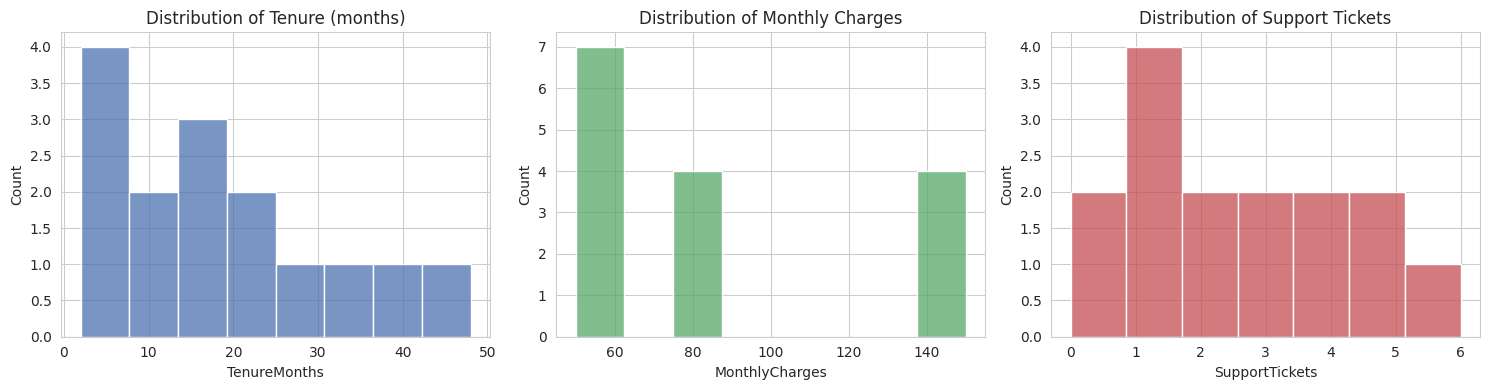

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_clean['TenureMonths'], bins=8, kde=False, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Tenure (months)')
sns.histplot(df_clean['MonthlyCharges'], bins=8, kde=False, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of Monthly Charges')
sns.histplot(df_clean['SupportTickets'], bins=7, kde=False, ax=axes[2], color='#C44E52')
axes[2].set_title('Distribution of Support Tickets')
plt.tight_layout()
plt.show()


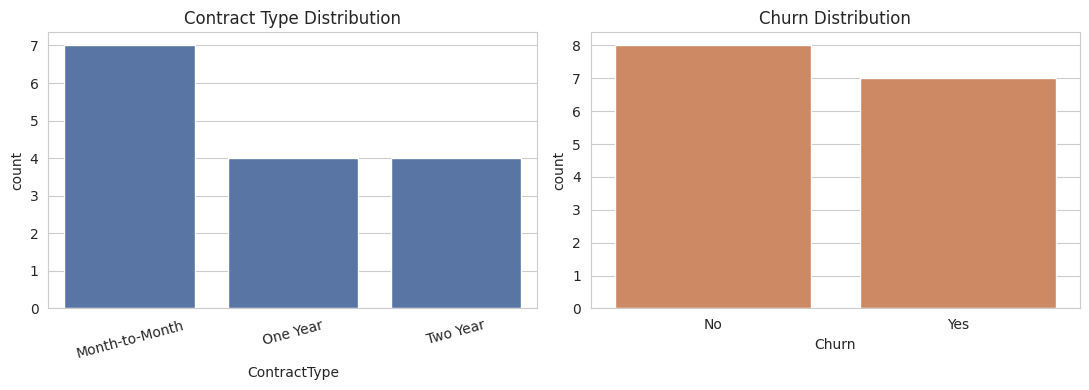

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df_clean, x='ContractType', order=['Month-to-Month', 'One Year', 'Two Year'],
              ax=axes[0], color='#4C72B0')
axes[0].set_title('Contract Type Distribution')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df_clean, x='Churn', order=['No', 'Yes'], ax=axes[1], color='#DD8452')
axes[1].set_title('Churn Distribution')
plt.tight_layout()
plt.show()


## 10. Initial Churn Patterns




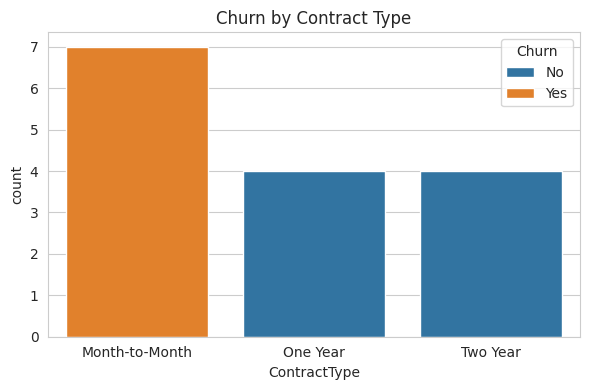

In [90]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_clean, x='ContractType', hue='Churn',
              order=['Month-to-Month', 'One Year', 'Two Year'], ax=ax)
ax.set_title('Churn by Contract Type')
plt.tight_layout()
plt.show()


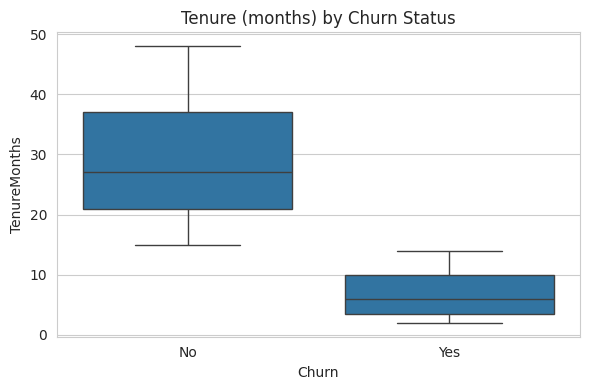

In [91]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x='Churn', y='TenureMonths', order=['No', 'Yes'], ax=ax)
ax.set_title('Tenure (months) by Churn Status')
plt.tight_layout()
plt.show()


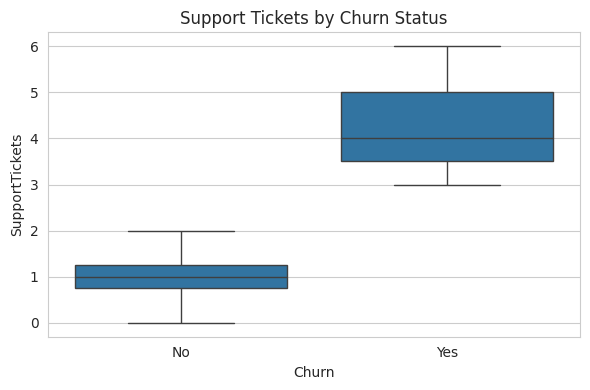

In [92]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x='Churn', y='SupportTickets', order=['No', 'Yes'], ax=ax)
ax.set_title('Support Tickets by Churn Status')
plt.tight_layout()
plt.show()


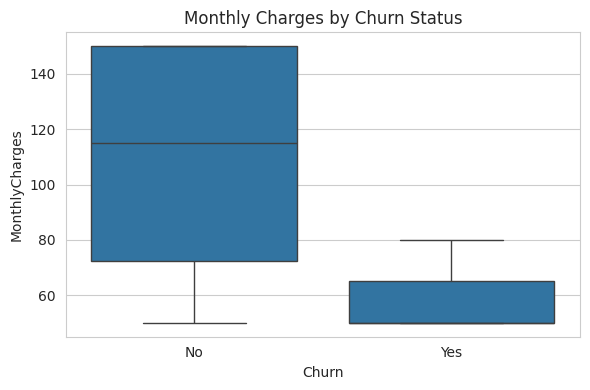

In [93]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', order=['No', 'Yes'], ax=ax)
ax.set_title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()


In [94]:
contract_churn = pd.crosstab(df_clean['ContractType'], df_clean['Churn'])
contract_churn['Churn Rate %'] = (contract_churn['Yes'] / contract_churn.sum(axis=1) * 100).round(1)
print("Churn by contract type:")
display(contract_churn)


Churn by contract type:


Churn,No,Yes,Churn Rate %
ContractType,,,
Month-to-Month,0,7,100.0
One Year,4,0,0.0
Two Year,4,0,0.0


## 11. Customer Group Analysis




In [95]:
df_clean['TenureGroup'] = np.where(df_clean['TenureMonths'] < 12,
                                    'Newer (<12 months)', 'Longer-tenure (12+ months)')
df_clean['SupportGroup'] = np.where(df_clean['SupportTickets'] <= 2,
                                     'Lower (0-2 tickets)', 'Higher (3+ tickets)')
df_clean['ChargeGroup'] = np.where(df_clean['MonthlyCharges'] < 79.99,
                                    'Lower charge (<$79.99)', 'Higher charge ($79.99+)')

for group_col in ['TenureGroup', 'SupportGroup', 'ChargeGroup']:
    tab = pd.crosstab(df_clean[group_col], df_clean['Churn'])
    tab['Churn Rate %'] = (tab.get('Yes', 0) / tab.sum(axis=1) * 100).round(1)
    print(f"--- {group_col} ---")
    display(tab)
    print()


--- TenureGroup ---


Churn,No,Yes,Churn Rate %
TenureGroup,,,
Longer-tenure (12+ months),8,2,20.0
Newer (<12 months),0,5,100.0



--- SupportGroup ---


Churn,No,Yes,Churn Rate %
SupportGroup,,,
Higher (3+ tickets),0,7,100.0
Lower (0-2 tickets),8,0,0.0



--- ChargeGroup ---


Churn,No,Yes,Churn Rate %
ChargeGroup,,,
Higher charge ($79.99+),6,2,25.0
Lower charge (<$79.99),2,5,71.4


## 12. Decision Analysis



In [96]:
def group_report(col, label):
    tab = pd.crosstab(df_clean[col], df_clean['Churn'])
    rows = []
    for group, row in tab.iterrows():
        n = row.sum()
        churned = row.get('Yes', 0)
        rate = round(churned / n * 100, 1) if n else 0
        rows.append({
            "Customer Group": group,
            "Segment": label,
            "Number of Customers": n,
            "Churn Count": churned,
            "Churn Rate %": rate,
        })
    return rows

report_rows = []
report_rows += group_report('ContractType', 'Contract Type')
report_rows += group_report('TenureGroup', 'Tenure')
report_rows += group_report('SupportGroup', 'Support Tickets')
report_rows += group_report('ChargeGroup', 'Monthly Charge')

decision_table = pd.DataFrame(report_rows).sort_values('Churn Rate %', ascending=False)
display(decision_table)


,Customer Group,Segment,Number of Customers,Churn Count,Churn Rate %
0,Month-to-Month,Contract Type,7,7,100.0
4,Newer (<12 months),Tenure,5,5,100.0
5,Higher (3+ tickets),Support Tickets,7,7,100.0
8,Lower charge (<$79.99),Monthly Charge,7,5,71.4
7,Higher charge ($79.99+),Monthly Charge,8,2,25.0
3,Longer-tenure (12+ months),Tenure,10,2,20.0
2,Two Year,Contract Type,4,0,0.0
1,One Year,Contract Type,4,0,0.0
6,Lower (0-2 tickets),Support Tickets,8,0,0.0


## Export Deliverables

In [97]:
export_cols = ['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType',
               'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets',
               'PaymentMethod', 'Churn']
df_clean[export_cols].to_csv('clean_customer_churn.csv', index=False)
print("Saved clean_customer_churn.csv")
print(f"Final shape: {df_clean.shape}")


Saved clean_customer_churn.csv
Final shape: (15, 14)
